# 🏦 Production-Grade Indian Retail Banking Churn Prediction System
This project is a comprehensive implementation of a production-grade machine learning system designed to predict customer churn in the Indian retail banking sector. The system encompasses all stages of the machine learning lifecycle, from data preprocessing to model training, evaluation, and deployment. The project is structured to follow best practices in software engineering and machine learning, ensuring scalability, maintainability, and robustness.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Overview

In [10]:
df = pd.read_csv('../data/raw/Indian_bank_churn_orig.csv')

In [11]:
df.shape

(50000, 20)

In [12]:
df.head()

,CustomerID,Age,Gender,City,Employment_Type,Annual_Income,Credit_Score,Tenure_Months,Avg_Monthly_Balance,Balance_Change_Ratio,Mobile_App_Logins,UPI_Transactions,ATM_Withdrawals,NetBanking_Usage,Complaint_Tickets,Call_Center_Interactions,Has_Credit_Card,Has_Loan,Has_Insurance,Churn
0,IB000001,54,Male,Rajkot,Business,1130100.0,684.0,163,110960.0,-0.0256,5.0,10.0,NaN,7.0,1.0,3.0,1,0,1,0
1,IB000002,28,Female,Jaipur,Salaried,472700.0,626.0,103,32200.0,0.0649,19.0,18.0,2.0,8.0,0.0,5.0,1,0,0,0
2,IB000003,35,Female,Bengaluru,Salaried,742800.0,637.0,126,42100.0,0.0616,6.0,12.0,NaN,6.0,0.0,2.0,1,0,0,0
3,IB000004,37,Female,Vadodara,Student,273000.0,550.0,91,8820.0,-0.0372,9.0,8.0,2.0,9.0,1.0,1.0,0,0,0,0
4,IB000005,26,Male,Pune,Salaried,1294000.0,590.0,67,137960.0,-0.1253,12.0,26.0,5.0,17.0,0.0,1.0,0,0,0,0


In [13]:
df.tail()

,CustomerID,Age,Gender,City,Employment_Type,Annual_Income,Credit_Score,Tenure_Months,Avg_Monthly_Balance,Balance_Change_Ratio,Mobile_App_Logins,UPI_Transactions,ATM_Withdrawals,NetBanking_Usage,Complaint_Tickets,Call_Center_Interactions,Has_Credit_Card,Has_Loan,Has_Insurance,Churn
49995,IB049996,38,Female,Agra,Business,1354500.0,667.0,158,168650.0,0.1926,11.0,14.0,4.0,13.0,1.0,1.0,1,0,0,0
49996,IB049997,30,Male,Ludhiana,Self_Employed,1415700.0,644.0,79,74130.0,0.1168,9.0,14.0,3.0,8.0,3.0,3.0,1,1,0,0
49997,IB049998,29,Female,Bhopal,Salaried,968300.0,590.0,49,41680.0,-0.2109,8.0,6.0,6.0,8.0,0.0,2.0,0,1,1,0
49998,IB049999,69,Male,Jaipur,Student,263400.0,706.0,151,8030.0,-0.1381,NaN,NaN,1.0,NaN,1.0,1.0,0,0,0,0
49999,IB050000,41,Female,Pune,Business,2270800.0,669.0,130,NaN,NaN,7.0,19.0,4.0,11.0,2.0,3.0,1,1,1,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                50000 non-null  object 
 1   Age                       50000 non-null  int64  
 2   Gender                    50000 non-null  object 
 3   City                      50000 non-null  object 
 4   Employment_Type           50000 non-null  object 
 5   Annual_Income             41370 non-null  float64
 6   Credit_Score              47619 non-null  float64
 7   Tenure_Months             50000 non-null  int64  
 8   Avg_Monthly_Balance       43992 non-null  float64
 9   Balance_Change_Ratio      43992 non-null  float64
 10  Mobile_App_Logins         43719 non-null  float64
 11  UPI_Transactions          43719 non-null  float64
 12  ATM_Withdrawals           43029 non-null  float64
 13  NetBanking_Usage          43719 non-null  float64
 14  Compla

In [15]:
df.describe()

,Age,Annual_Income,Credit_Score,Tenure_Months,Avg_Monthly_Balance,Balance_Change_Ratio,Mobile_App_Logins,UPI_Transactions,ATM_Withdrawals,NetBanking_Usage,Complaint_Tickets,Call_Center_Interactions,Has_Credit_Card,Has_Loan,Has_Insurance,Churn
count,50000.000000,4.137000e+04,47619.000000,50000.000000,43992.000000,43992.000000,43719.000000,43719.000000,43029.000000,43719.000000,47609.000000,42950.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,45.841220,7.555104e+05,653.972028,119.474200,54090.583288,-0.082582,8.197557,12.851026,3.823561,5.737300,1.387364,2.289709,0.470380,0.289940,0.334920,0.17452
std,14.706553,4.821072e+05,54.384398,44.528436,58759.334344,0.177666,3.684876,5.407704,2.199561,3.260219,1.301023,1.524213,0.499127,0.453739,0.471967,0.37956
min,21.000000,1.200000e+05,437.000000,1.000000,500.000000,-0.741000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,33.000000,4.383000e+05,618.000000,95.000000,18860.000000,-0.146000,5.000000,9.000000,2.000000,3.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000
50%,46.000000,6.686000e+05,654.000000,127.000000,37690.000000,-0.064900,8.000000,12.000000,4.000000,5.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.00000
75%,59.000000,9.437000e+05,690.000000,151.000000,67660.000000,0.019700,11.000000,17.000000,5.000000,8.000000,2.000000,3.000000,1.000000,1.000000,1.000000,0.00000
max,71.000000,6.000000e+06,883.000000,240.000000,886160.000000,0.739600,26.000000,36.000000,16.000000,23.000000,12.000000,11.000000,1.000000,1.000000,1.000000,1.00000


### Numerical Feature Analysis
- This description shows wide range of numbers from 0 to 1,000,000, which indicates that the dataset contains a mix of small and large values. So we need to apply feature scaling techniques such as Standardization or Min-Max Scaling to ensure that the features are on a similar scale.
- Minimum age is 21 and maximum age is 71 with majority range between 30 to 50, which indicates that the dataset contains customers of varying ages, with a concentration in the middle age range. T
- Tenure month range from 1 to 240
- annual income range from 1.200000e+05 to 6.000000e+06
- BAlance change ratio range from -0.74 to 0.73
- Mobile_App_Logins, UPI_Transactions, ATM_Withdrawals, NetBanking_Usage can be 0 also means some customers have not used these services at all, while others have used them frequently. MAx value range upto 30 for all these features
- Complaint_Tickets, Call_Center_Interactions are also not majorly used by customers, with many having 0 interactions, but some customers have had up to 12 complaint tickets and 11 call center interactions. 
- Has_Credit_Card, Has_Loan, Has_Insurance all are binary features with 0 and 1 values, which indicates whether a customer has a credit card, loan, or insurance, respectively. The presence of these features can be important for predicting churn, as customers with certain financial products may be more likely to stay with the bank.

In [16]:
df.describe(include='object')

,CustomerID,Gender,City,Employment_Type
count,50000,50000,50000,50000
unique,50000,2,40,5
top,IB049984,Male,Mumbai,Salaried
freq,1,28064,3793,22806


### Categorical Feature Analysis
- This shows that "Employment_Type" is ordinal data with a clear hierarchy
- while "City" is nominal data without any inherent order. 
- "Gender" is a binary categorical variable
- "CustomerID" is a unique identifier that does not have any categorical meaning.

## Overall Dataset Summary

Dataset used in this project is the "Indian Bank Churn Dataset," which contains information about customers of an Indian retail bank, including their demographic details, account information, and whether they have churned (i.e., closed their accounts). 
- The dataset ahs total 50000 records and 20 features
- The 1 target variable is "Churn," which indicates whether a customer has churned (1) or not (0).
- There are 4 categorical features(CustomerID, Gender, City, Employment_Type)
- There are 15 numerical Features('Age', 'Annual_Income', 'Credit_Score', 'Tenure_Months', 'Avg_Monthly_Balance','Balance_Change_Ratio', 'Mobile_App_Logins', 'UPI_Transactions',
       'ATM_Withdrawals', 'NetBanking_Usage', 'Complaint_Tickets',
       'Call_Center_Interactions', 'Has_Credit_Card', 'Has_Loan',
       'Has_Insurance')



# Target Variable Analysis

In [25]:
df['Churn'].value_counts()


Churn
0    41274
1     8726
Name: count, dtype: int64

In [23]:
churn_rate = df["Churn"].mean()*100
print(f"Churn Rate: {churn_rate:.2f}%")

Churn Rate: 17.45%


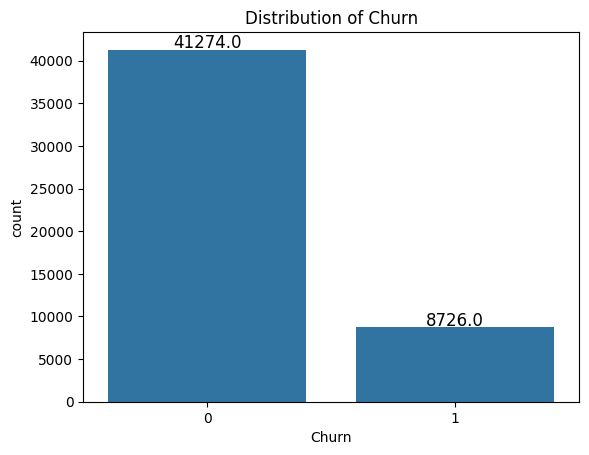

In [28]:
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn')
#add count labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()

- The dataset is imbalanced, with a higher proportion of non-churned customers compared to churned customers. This imbalance will be addressed during the model training phase using techniques such as SMOTE (Synthetic Minority Over-sampling Technique) or class weighting.
- Accurate prediction of churn is crucial for the bank, as it can help in retaining customers and improving customer satisfaction. The imbalance in the target variable may require the use of specialized evaluation metrics such as Precision, Recall, F1-score, and AUC-ROC to ensure that the model performs well on both classes.
- The distribution of the target variable suggests that the bank has a relatively low churn rate, which is a positive sign for the business. However, it also means that the model will need to be particularly effective at identifying the minority class (churned customers) to be useful in a real-world setting.

# Missing Values Analysis

In [29]:
df.isnull().sum()

CustomerID                     0
Age                            0
Gender                         0
City                           0
Employment_Type                0
Annual_Income               8630
Credit_Score                2381
Tenure_Months                  0
Avg_Monthly_Balance         6008
Balance_Change_Ratio        6008
Mobile_App_Logins           6281
UPI_Transactions            6281
ATM_Withdrawals             6971
NetBanking_Usage            6281
Complaint_Tickets           2391
Call_Center_Interactions    7050
Has_Credit_Card                0
Has_Loan                       0
Has_Insurance                  0
Churn                          0
dtype: int64

In [30]:
(df.isnull().sum() / len(df)) * 100


CustomerID                   0.000
Age                          0.000
Gender                       0.000
City                         0.000
Employment_Type              0.000
Annual_Income               17.260
Credit_Score                 4.762
Tenure_Months                0.000
Avg_Monthly_Balance         12.016
Balance_Change_Ratio        12.016
Mobile_App_Logins           12.562
UPI_Transactions            12.562
ATM_Withdrawals             13.942
NetBanking_Usage            12.562
Complaint_Tickets            4.782
Call_Center_Interactions    14.100
Has_Credit_Card              0.000
Has_Loan                     0.000
Has_Insurance                0.000
Churn                        0.000
dtype: float64

In [ ]:
missing_value_columns = df.columns[df.isnull().any()]
missing_value_columns

Index(['Annual_Income', 'Credit_Score', 'Avg_Monthly_Balance',
       'Balance_Change_Ratio', 'Mobile_App_Logins', 'UPI_Transactions',
       'ATM_Withdrawals', 'NetBanking_Usage', 'Complaint_Tickets',
       'Call_Center_Interactions'],
      dtype='object')

- Overall datset has upto 7-8% missing values in some features
- As this is banking dataset, we can not drop the records with missing values as it may lead to loss of important information, instead we will impute the missing values using appropriate techniques.
- 'Annual_Income', 'Credit_Score', 'Avg_Monthly_Balance',
       'Balance_Change_Ratio', 'Mobile_App_Logins', 'UPI_Transactions',
       'ATM_Withdrawals', 'NetBanking_Usage', 'Complaint_Tickets',
       'Call_Center_Interactions' are the features with missing values. 
- We will decide imputation method based on the distribution of these features and the percentage of missing values. For example, if a feature has a normal distribution and a low percentage of missing values, we may choose mean imputation. If a feature has a skewed distribution or a high percentage of missing values, we may choose median imputation or KNN imputation.
- Tree-based models (RandomForest, XGBoost) do not require scaling.
Logistic regression and SVM do.
Since we plan multiple models, scaling pipeline will be useful.

# Univariate Analysis
Now we will perform univariate analysis on the numerical and categorical features to understand their distributions independtly and identify any potential outliers or patterns in the data.

In [ ]:
# Numerical features
Numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical Features:")
print(Numerical_features)

Categorical_features = df.select_dtypes(include=['object']).columns
print("Categorical Features:")
print(Categorical_features)

Numerical Features:
Index(['Age', 'Annual_Income', 'Credit_Score', 'Tenure_Months',
       'Avg_Monthly_Balance', 'Balance_Change_Ratio', 'Mobile_App_Logins',
       'UPI_Transactions', 'ATM_Withdrawals', 'NetBanking_Usage',
       'Complaint_Tickets', 'Call_Center_Interactions', 'Has_Credit_Card',
       'Has_Loan', 'Has_Insurance', 'Churn'],
      dtype='object')
Categorical Features:
Index(['CustomerID', 'Gender', 'City', 'Employment_Type'], dtype='object')


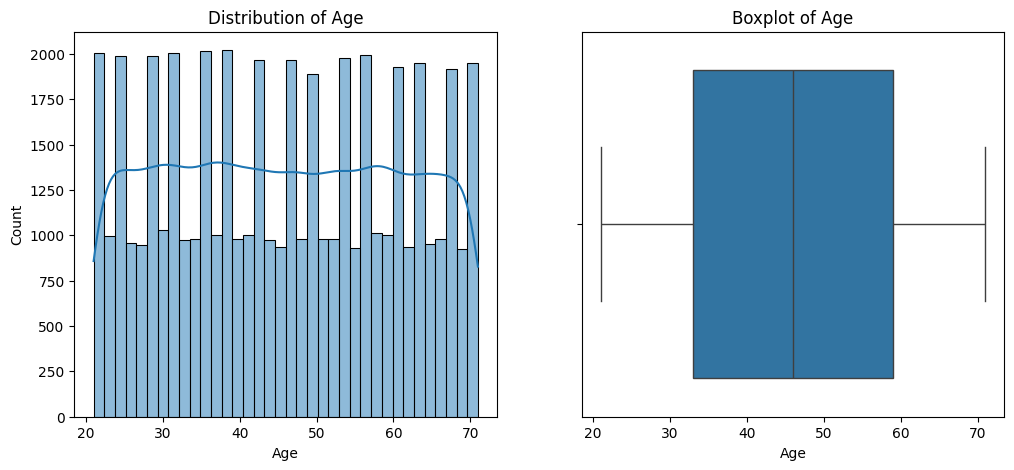

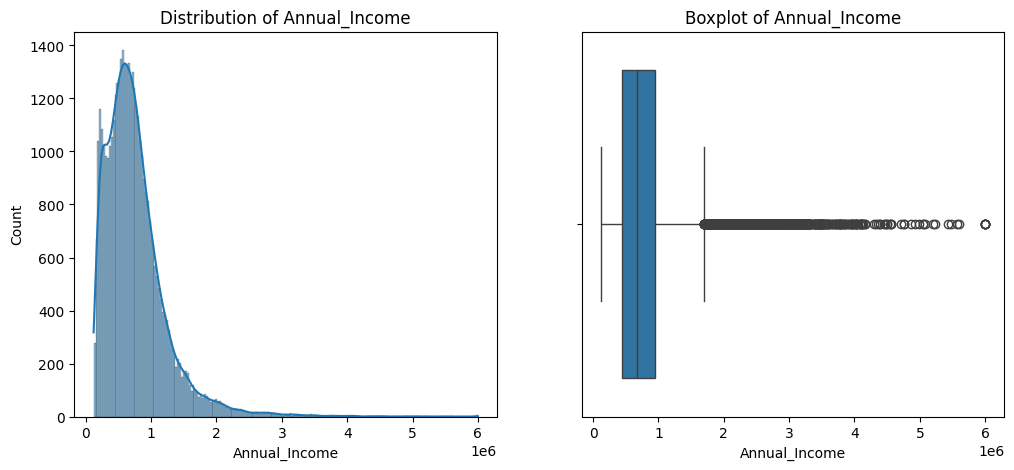

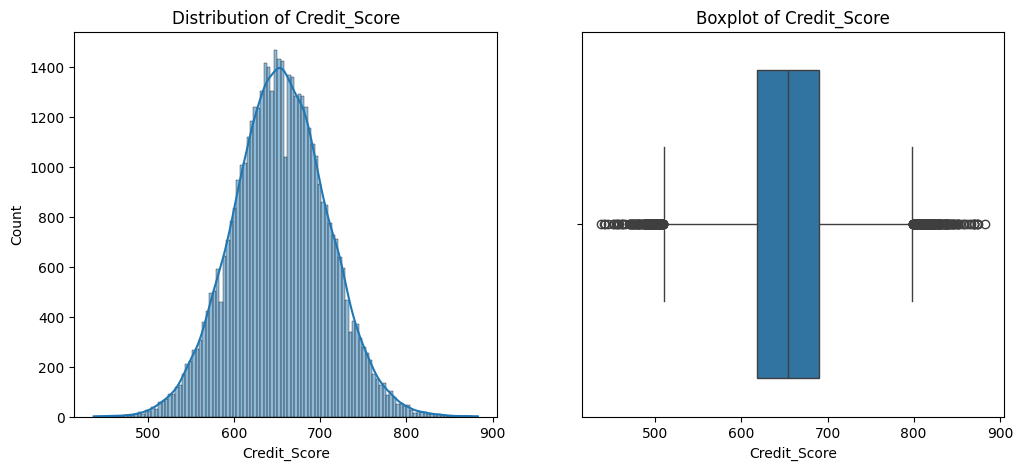

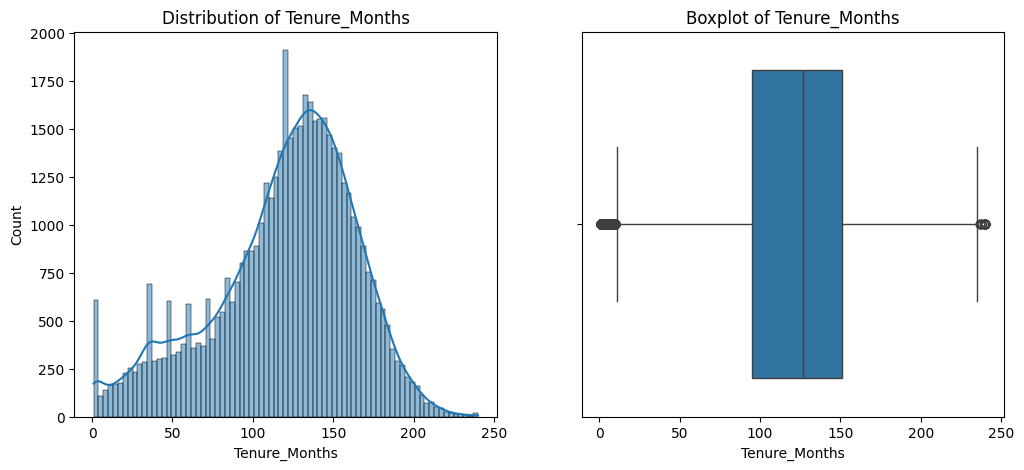

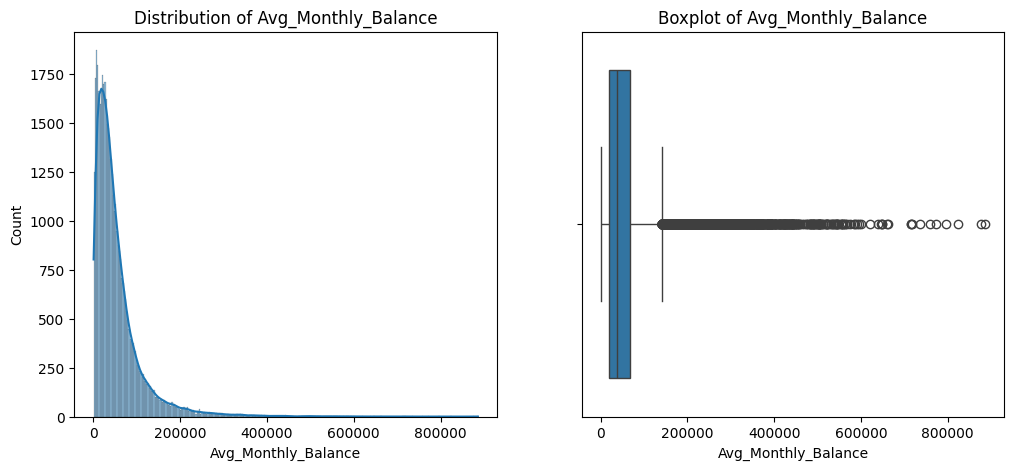

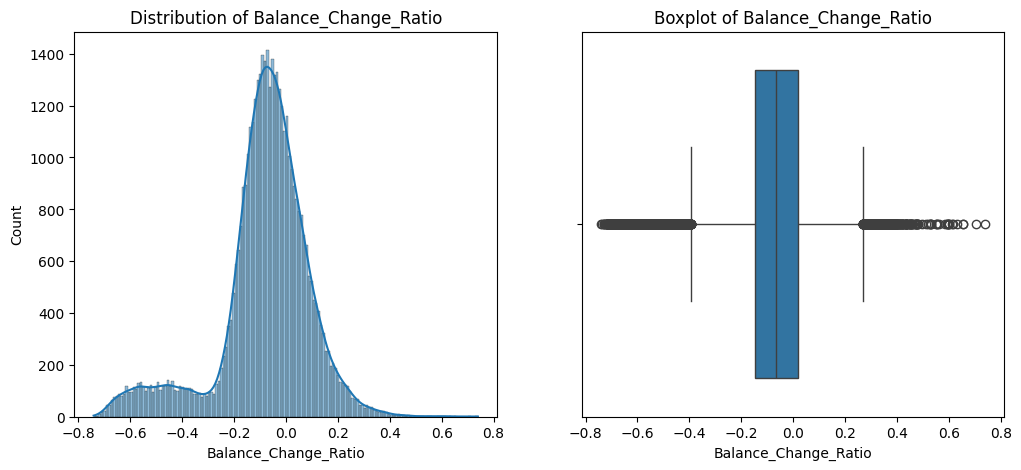

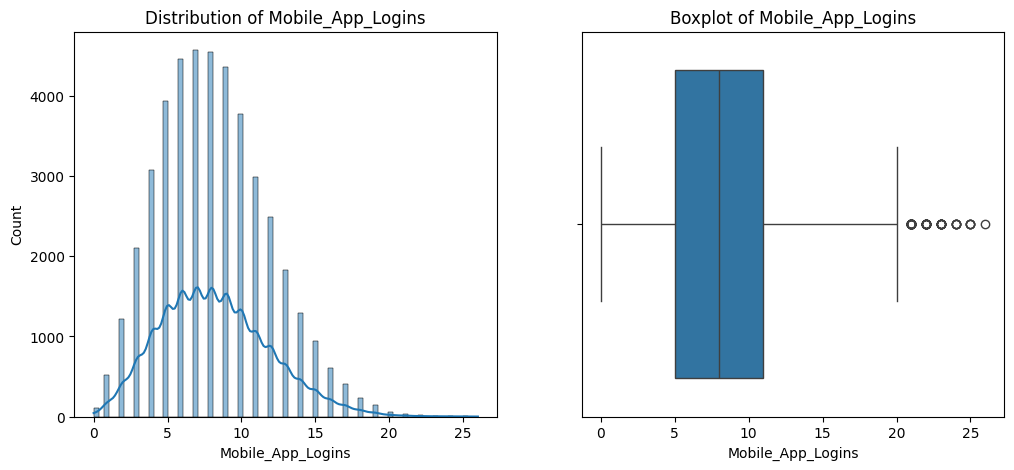

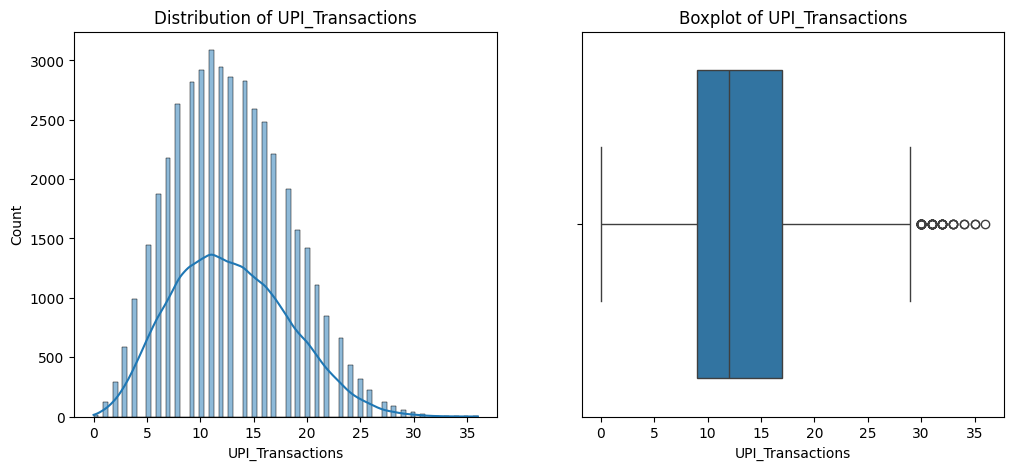

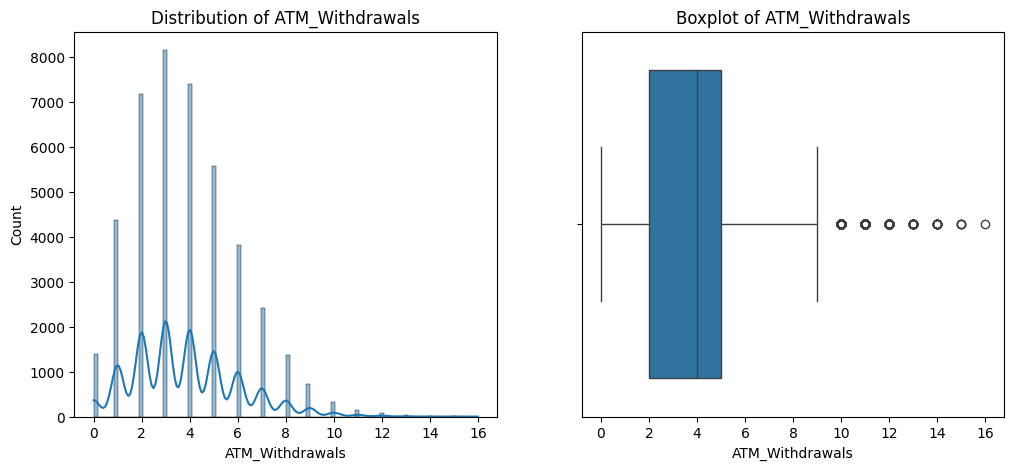

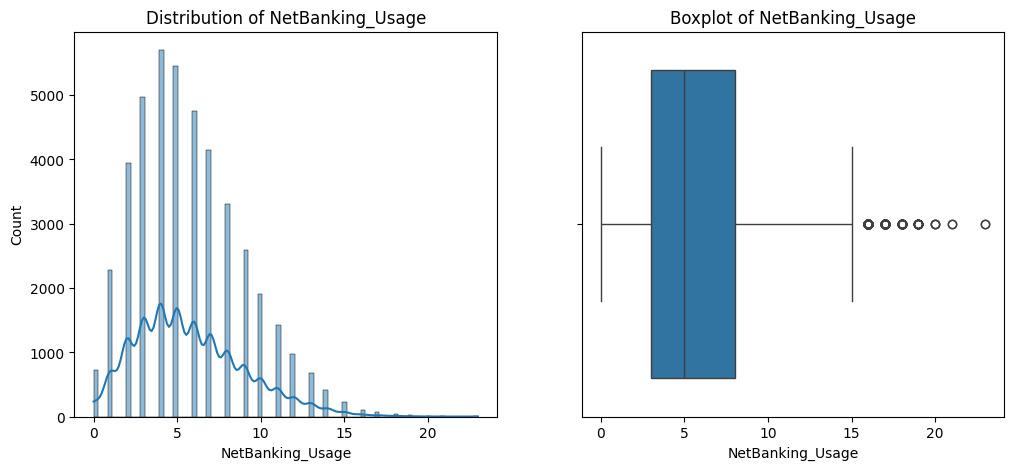

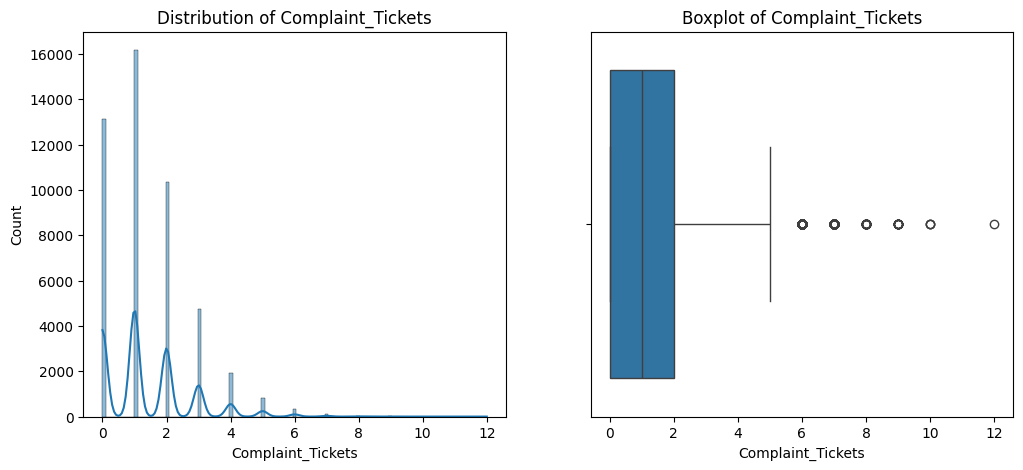

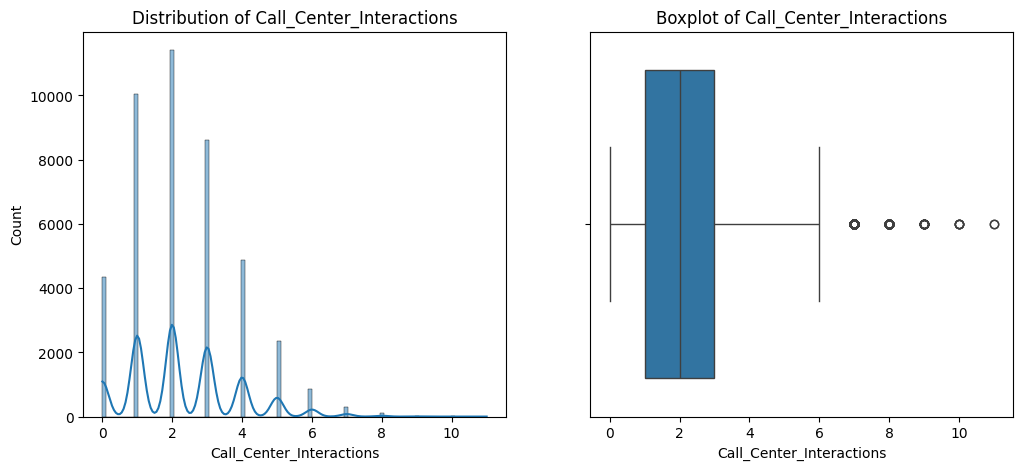

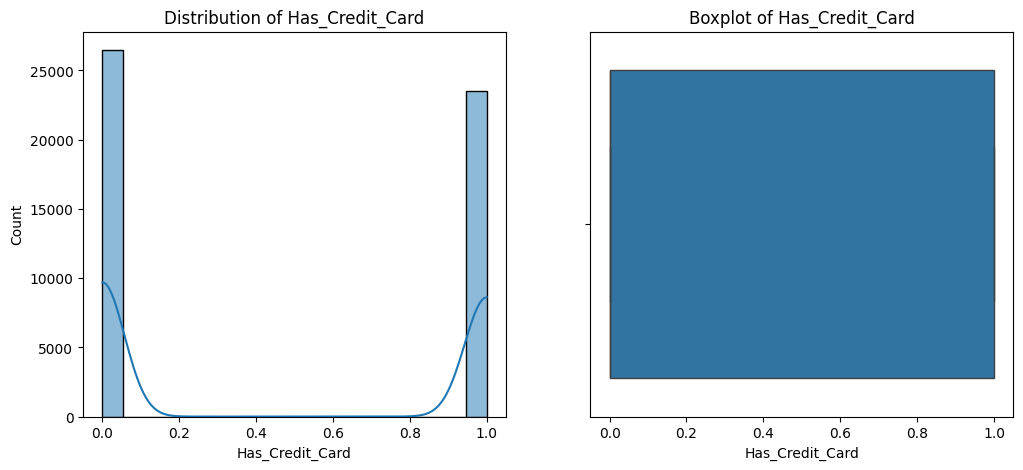

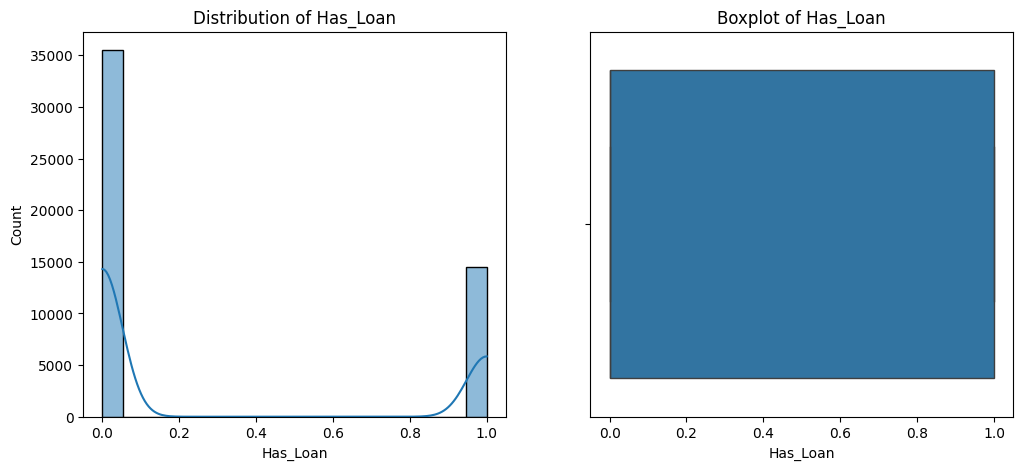

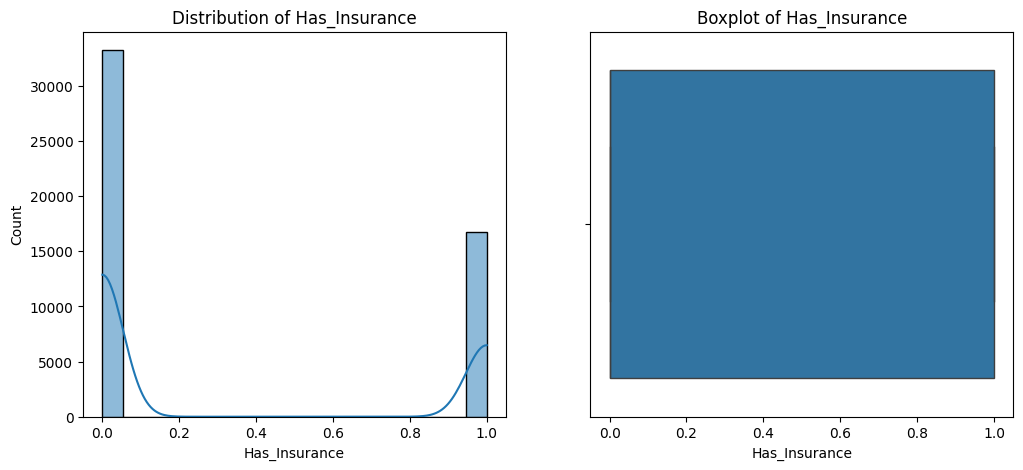

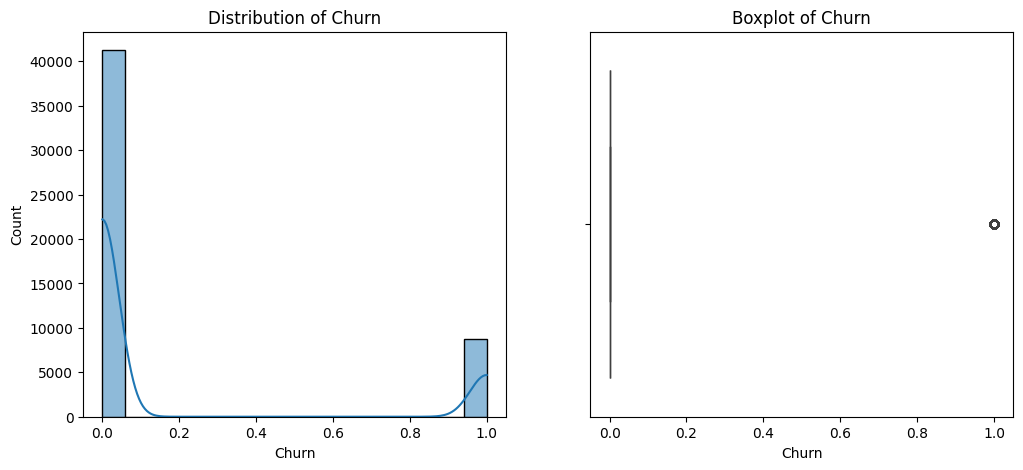

In [36]:
# Function to plot distribution of numerical features - histogram and boxplot
def plot_numerical_features(df, numerical_features):
    for feature in numerical_features:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        sns.histplot(df[feature], kde=True)
        plt.title(f'Distribution of {feature}')
        
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[feature])
        plt.title(f'Boxplot of {feature}')
        
        plt.show()

plot_numerical_features(df, Numerical_features)

# Bivariate Analysis

#### For Categorical Feature

A. Employment Type vs Churn

Churn                    0          1
Employment_Type                      
Business         88.512373  11.487627
Retired          81.304506  18.695494
Salaried         82.294133  17.705867
Self_Employed    84.058406  15.941594
Student          72.745141  27.254859


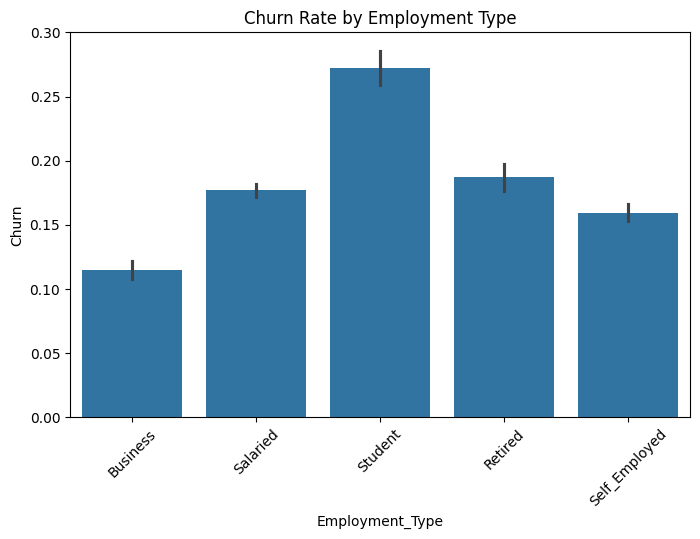

In [45]:
# Crosstab with churn rate
emp_churn = pd.crosstab(df['Employment_Type'], df['Churn'], normalize='index') * 100
print(emp_churn)

# Bar plot
plt.figure(figsize=(8,5))
sns.barplot(x='Employment_Type', y='Churn', data=df)
plt.title("Churn Rate by Employment Type")
plt.xticks(rotation=45)
plt.show()

B. Gender vs Churn

Churn           0          1
Gender                      
Female  82.877462  17.122538
Male    82.290479  17.709521


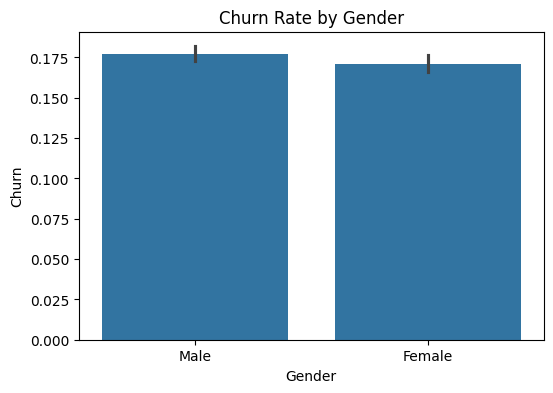

In [46]:
gender_churn = pd.crosstab(df['Gender'], df['Churn'], normalize='index') * 100
print(gender_churn)

plt.figure(figsize=(6,4))
sns.barplot(x='Gender', y='Churn', data=df)
plt.title("Churn Rate by Gender")
plt.show()

C. Has_Loan / Has_Credit_Card / Has_Insurance vs Churn


Churn Rate by Has_Loan
Churn             0          1
Has_Loan                      
0         79.663690  20.336310
1         89.611644  10.388356


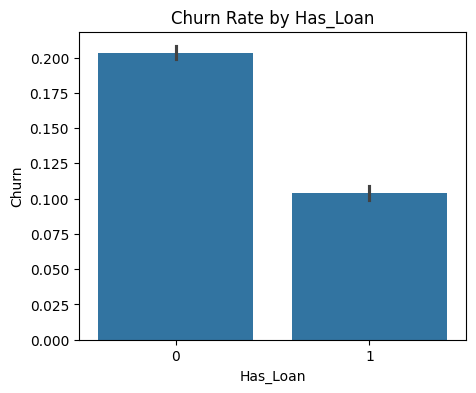


Churn Rate by Has_Credit_Card
Churn                    0          1
Has_Credit_Card                      
0                79.241720  20.758280
1                86.270675  13.729325


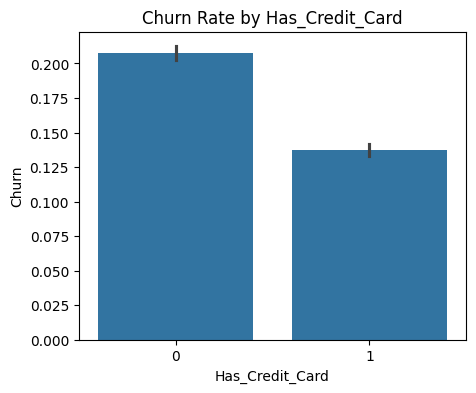


Churn Rate by Has_Insurance
Churn                  0          1
Has_Insurance                      
0              80.501594  19.498406
1              86.611728  13.388272


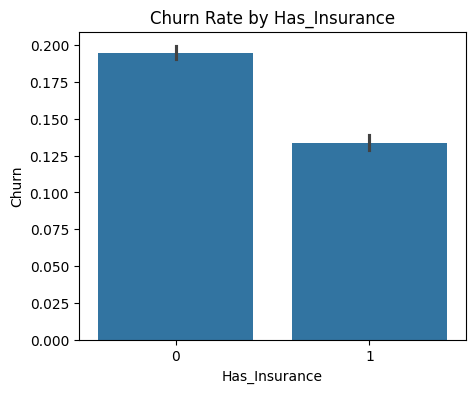

In [47]:
product_features = ['Has_Loan', 'Has_Credit_Card', 'Has_Insurance']

for col in product_features:
    print(f"\nChurn Rate by {col}")
    print(pd.crosstab(df[col], df['Churn'], normalize='index') * 100)

    plt.figure(figsize=(5,4))
    sns.barplot(x=col, y='Churn', data=df)
    plt.title(f"Churn Rate by {col}")
    plt.show()

#### For Numerical Feature

A. Tenure Buckets vs Churn

Churn                  0          1
Tenure_Bucket                      
0-2 yrs        66.894198  33.105802
2-5 yrs        73.050884  26.949116
5-10 yrs       79.261382  20.738618
10+ yrs        86.933972  13.066028


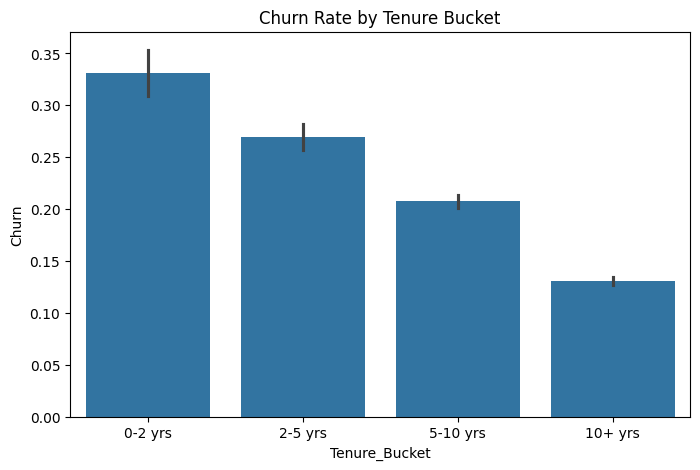

In [48]:
# Create temporary tenure buckets
df['Tenure_Bucket'] = pd.cut(
    df['Tenure_Months'],
    bins=[0, 24, 60, 120, 240],
    labels=['0-2 yrs', '2-5 yrs', '5-10 yrs', '10+ yrs']
)

tenure_churn = pd.crosstab(df['Tenure_Bucket'], df['Churn'], normalize='index') * 100
print(tenure_churn)

plt.figure(figsize=(8,5))
sns.barplot(x='Tenure_Bucket', y='Churn', data=df)
plt.title("Churn Rate by Tenure Bucket")
plt.show()

Tenure vs Churn → Negative Correlation
- Longer tenure reduces churn probability
- Loyal customers are less likely to churn.
- Modeling Implication:
Tenure is a core retention signal.

B. Balance vs Churn

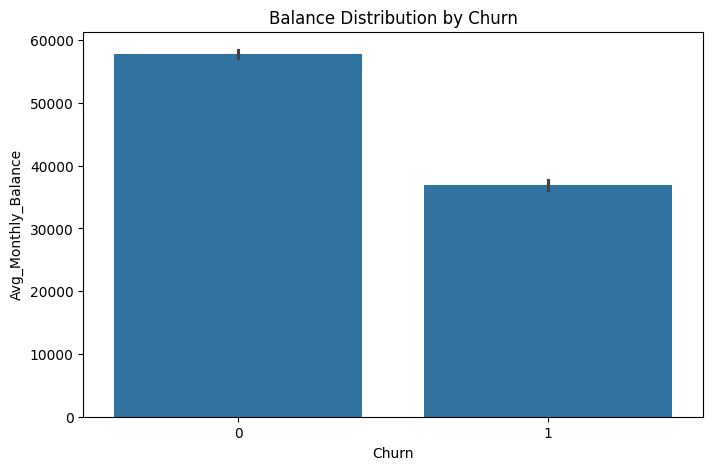

Churn
0    57745.148209
1    36844.001560
Name: Avg_Monthly_Balance, dtype: float64


In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x='Churn', y='Avg_Monthly_Balance', data=df)
plt.title("Balance Distribution by Churn")
plt.show()

print(df.groupby('Churn')['Avg_Monthly_Balance'].mean())

C. Credit Score vs Churn

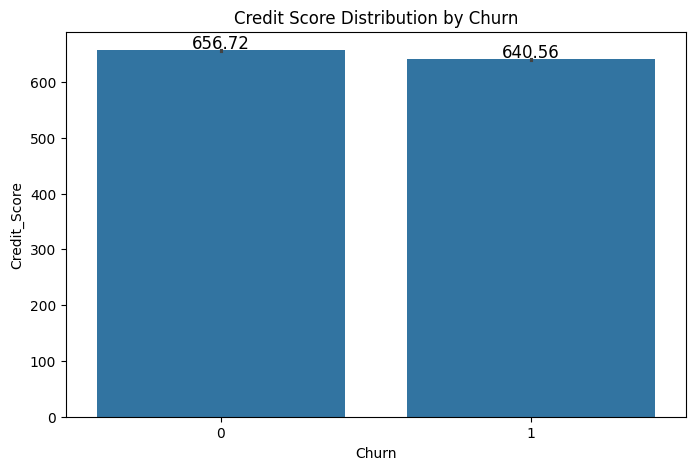

Churn
0    656.722196
1    640.558257
Name: Credit_Score, dtype: float64


In [56]:
plt.figure(figsize=(8,5))
sns.barplot(x='Churn', y='Credit_Score', data=df)
#add labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.title("Credit Score Distribution by Churn")
plt.show()

print(df.groupby('Churn')['Credit_Score'].mean())

D. Complaint Tickets vs Churn

Churn                      0          1
Complaint_Tickets                      
0.0                88.770217  11.229783
1.0                88.217112  11.782888
2.0                79.911103  20.088897
3.0                76.125368  23.874632
4.0                49.317943  50.682057
5.0                43.425814  56.574186
6.0                39.393939  60.606061
7.0                29.203540  70.796460
8.0                29.629630  70.370370
9.0                30.769231  69.230769


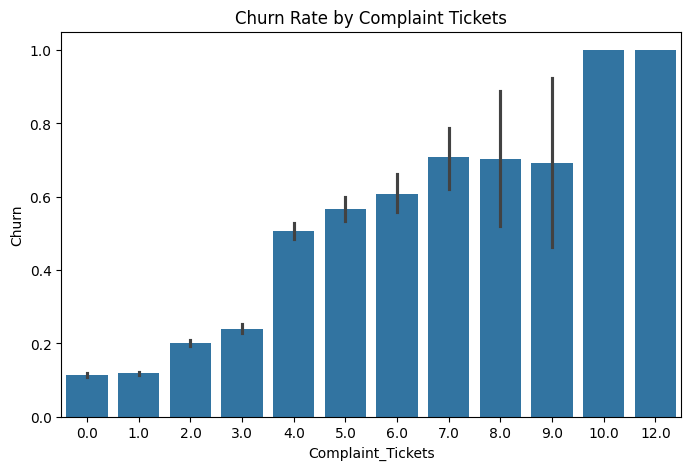

In [57]:
complaint_churn = pd.crosstab(df['Complaint_Tickets'], df['Churn'], normalize='index') * 100
print(complaint_churn.head(10))

plt.figure(figsize=(8,5))
sns.barplot(x='Complaint_Tickets', y='Churn', data=df)
plt.title("Churn Rate by Complaint Tickets")
plt.show()

Complaint_Tickets vs Churn → Positive Correlation
Complaint tickets show noticeable positive correlation with churn
Call center interactions also moderately aligned
- Customer dissatisfaction strongly increases churn risk.
- Modeling Implication: Complaint-based features will carry high importance.

E. Digital Engagement vs Churn (Mobile_App_Logins, UPI_Transactions, ATM_Withdrawals, NetBanking_Usage)

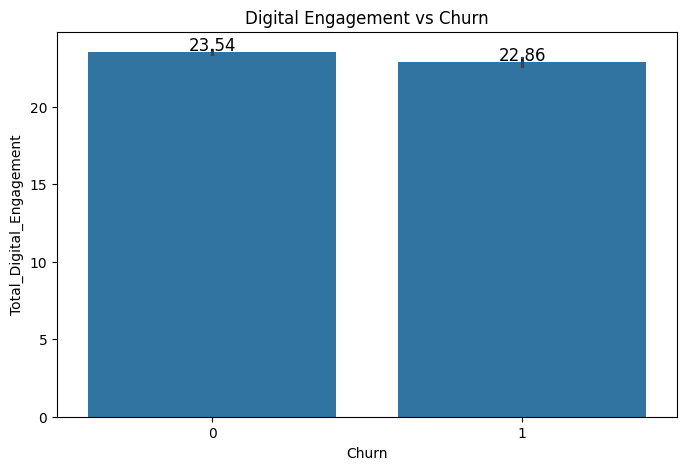

Churn
0    23.538693
1    22.864543
Name: Total_Digital_Engagement, dtype: float64


In [60]:
df['Total_Digital_Engagement'] = (
    df['Mobile_App_Logins'].fillna(0) +
    df['UPI_Transactions'].fillna(0) +
    df['NetBanking_Usage'].fillna(0)
)

plt.figure(figsize=(8,5))
sns.barplot(x='Churn', y='Total_Digital_Engagement', data=df)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.title("Digital Engagement vs Churn")
plt.show()

print(df.groupby('Churn')['Total_Digital_Engagement'].mean())

Digital Engagement vs Churn → Strong Negative Correlation
Total_Digital_Engagement shows clear negative correlation with Churn
Customers with higher app logins, UPI usage, and net banking usage churn less
- Digitally engaged customers are more sticky and less likely to leave.
- Modeling Implication: Engagement features will likely be strong predictors.

F. Balance Change Ratio vs Churn

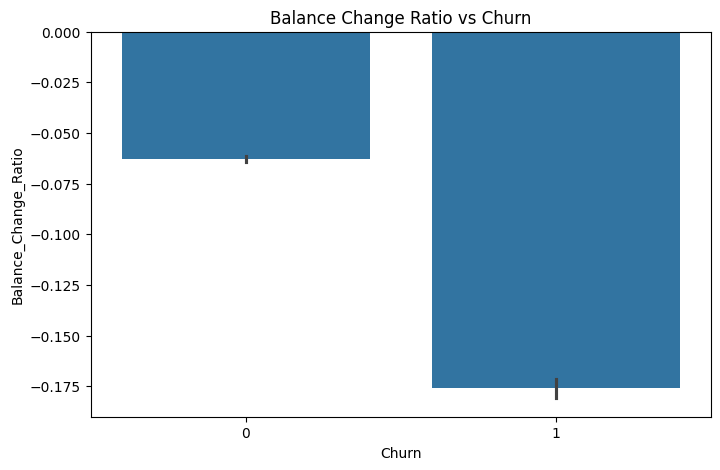

Churn
0   -0.062790
1   -0.175982
Name: Balance_Change_Ratio, dtype: float64


In [62]:
plt.figure(figsize=(8,5))
sns.barplot(x='Churn', y='Balance_Change_Ratio', data=df)
plt.title("Balance Change Ratio vs Churn")
plt.show()

print(df.groupby('Churn')['Balance_Change_Ratio'].mean())

Correlation Analysis

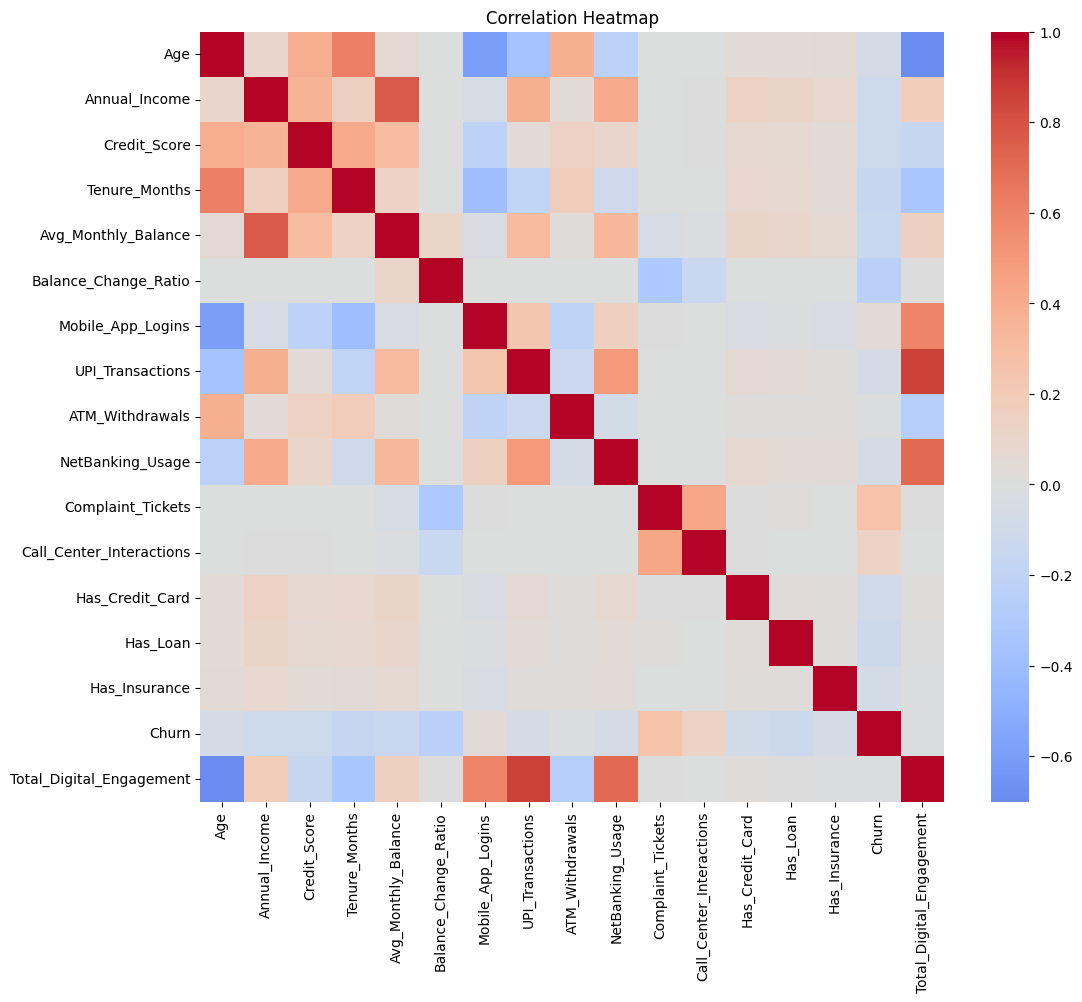

In [63]:
plt.figure(figsize=(12,10))
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

- From Correlation matrix - Complaint Ticket, Call Centre Interactions higly affect on churn rate
- also balnce change ratio, tenure months, avg monthly balance, credit score also affects on churn

## Modeling Implications

### From EDA, we conclude:
 - Stratified train-test split required (due to 17% churn)
 - Imbalance handling necessary (class weights / SMOTE)
 - Scaling required for linear models
 - Missing value imputation required
 - Feature engineering opportunities exist:
    - Engagement score
    - Tenure buckets
    - Product count
    - Balance drop indicator